# Preparación del dataset DeepPCB para YOLO

Este notebook implementa la transformación del dataset DeepPCB desde su estructura y formato de anotaciones originales hacia una estructura compatible con modelos YOLO de detección de objetos.

## Objetivos

- Reconstruir de manera reproducible las particiones `train`, `val` y `test`.
- Convertir las anotaciones originales de DeepPCB al formato requerido por YOLO.
- Generar una estructura de directorios compatible con Ultralytics.
- Preservar sin modificaciones el dataset original almacenado en `data/raw/`.
- Validar la integridad del dataset procesado.
- Verificar visualmente la correcta conversión de las *bounding boxes* antes del entrenamiento.

## 1. Importación de librerías y configuración de rutas

Se definen las dependencias y rutas principales del proyecto. El dataset original se utilizará únicamente como fuente de lectura, mientras que todos los archivos transformados se generarán dentro de `data/processed/`.

In [1]:
from pathlib import Path
import shutil

import cv2
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
# Detectar la raíz del proyecto
PROJECT_ROOT = Path.cwd().parent

# Dataset original
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DEEPPCB_DIR = DATA_RAW_DIR / "DeepPCB-master"
PCB_DATA_DIR = DEEPPCB_DIR / "PCBData"

TRAINVAL_FILE = PCB_DATA_DIR / "trainval.txt"
TEST_FILE = PCB_DATA_DIR / "test.txt"

# Dataset procesado para YOLO
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
YOLO_DATASET_DIR = DATA_PROCESSED_DIR / "deep_pcb_yolo"

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset original: {DEEPPCB_DIR}")
print(f"Dataset procesado: {YOLO_DATASET_DIR}")

Raíz del proyecto: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo
Dataset original: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\raw\DeepPCB-master
Dataset procesado: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\processed\deep_pcb_yolo


In [3]:
assert DEEPPCB_DIR.exists(), "No se encontró el dataset DeepPCB."
assert PCB_DATA_DIR.exists(), "No se encontró la carpeta PCBData."
assert TRAINVAL_FILE.exists(), "No se encontró trainval.txt."
assert TEST_FILE.exists(), "No se encontró test.txt."

print("Las rutas de entrada fueron validadas correctamente.")

Las rutas de entrada fueron validadas correctamente.


## 2. Reconstrucción reproducible de las particiones

DeepPCB proporciona originalmente dos particiones: `trainval`, con 1000 imágenes, y `test`, con 500 imágenes.

Para el presente proyecto, la partición `trainval` se subdivide en conjuntos de entrenamiento y validación mediante una separación 80/20 reproducible, utilizando una semilla aleatoria fija (`random_state=42`) y estratificación por grupo.

La partición `test` original se mantiene sin modificaciones y se reserva exclusivamente para la evaluación final de los modelos.

La estrategia final es:

- **Train:** 800 imágenes.
- **Validation:** 200 imágenes.
- **Test:** 500 imágenes.

In [4]:
def read_split_file(file_path: Path) -> list[str]:
    """
    Lee un archivo de partición de DeepPCB y devuelve
    sus entradas no vacías.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        return [
            line.strip()
            for line in file
            if line.strip()
        ]


trainval_samples = read_split_file(TRAINVAL_FILE)
test_samples = read_split_file(TEST_FILE)

print(f"Muestras originales en trainval: {len(trainval_samples)}")
print(f"Muestras originales en test: {len(test_samples)}")

Muestras originales en trainval: 1000
Muestras originales en test: 500


In [5]:
def resolve_test_image_path(image_rel_path: str) -> Path:
    """
    Convierte la ruta lógica indicada por DeepPCB
    en la ruta física de la imagen inspeccionada
    con sufijo _test.jpg.
    """
    logical_path = PCB_DATA_DIR / image_rel_path

    if logical_path.exists():
        return logical_path

    return logical_path.with_name(
        logical_path.stem + "_test" + logical_path.suffix
    )


def build_samples_dataframe(
    samples: list[str],
    original_split: str
) -> pd.DataFrame:
    """
    Construye un DataFrame con la información
    de las muestras de DeepPCB.
    """
    records = []

    for sample in samples:
        image_rel_path, annotation_rel_path = sample.split()

        records.append({
            "sample_id": Path(image_rel_path).stem,
            "group": Path(image_rel_path).parts[0],
            "original_split": original_split,
            "image_path": resolve_test_image_path(image_rel_path),
            "annotation_path": PCB_DATA_DIR / annotation_rel_path,
        })

    return pd.DataFrame(records)


df_trainval = build_samples_dataframe(
    trainval_samples,
    original_split="trainval"
)

df_test = build_samples_dataframe(
    test_samples,
    original_split="test"
)

print(f"Trainval: {len(df_trainval)} muestras")
print(f"Test: {len(df_test)} muestras")

Trainval: 1000 muestras
Test: 500 muestras


In [6]:
df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.20,
    random_state=42,
    stratify=df_trainval["group"]
)

df_test_final = df_test.copy()

print(f"Train: {len(df_train)} imágenes")
print(f"Validation: {len(df_val)} imágenes")
print(f"Test: {len(df_test_final)} imágenes")

Train: 800 imágenes
Validation: 200 imágenes
Test: 500 imágenes


In [7]:
# Validar existencia de archivos
for split_name, split_df in {
    "train": df_train,
    "val": df_val,
    "test": df_test_final,
}.items():

    missing_images = (
        ~split_df["image_path"].apply(lambda path: path.exists())
    ).sum()

    missing_annotations = (
        ~split_df["annotation_path"].apply(lambda path: path.exists())
    ).sum()

    print(
        f"{split_name}: "
        f"{missing_images} imágenes faltantes, "
        f"{missing_annotations} anotaciones faltantes"
    )


# Validar ausencia de solapamiento
train_ids = set(df_train["sample_id"])
val_ids = set(df_val["sample_id"])
test_ids = set(df_test_final["sample_id"])

assert train_ids.isdisjoint(val_ids), (
    "Existe solapamiento entre train y val."
)

assert train_ids.isdisjoint(test_ids), (
    "Existe solapamiento entre train y test."
)

assert val_ids.isdisjoint(test_ids), (
    "Existe solapamiento entre val y test."
)

print("\nNo se detectaron solapamientos entre particiones.")

train: 0 imágenes faltantes, 0 anotaciones faltantes
val: 0 imágenes faltantes, 0 anotaciones faltantes
test: 0 imágenes faltantes, 0 anotaciones faltantes

No se detectaron solapamientos entre particiones.


## 3. Conversión de anotaciones al formato YOLO

Las anotaciones originales de DeepPCB representan cada defecto mediante coordenadas absolutas en píxeles:

`x_min y_min x_max y_max class_id`

YOLO requiere una representación diferente:

`class_id x_center y_center width height`

donde las coordenadas y dimensiones de la *bounding box* se encuentran normalizadas respecto del ancho y alto de la imagen, tomando valores entre 0 y 1.

Además, DeepPCB utiliza identificadores de clase entre 1 y 6, mientras que YOLO requiere índices comenzando en 0. Por lo tanto, se aplica la transformación:

- 1 → 0
- 2 → 1
- 3 → 2
- 4 → 3
- 5 → 4
- 6 → 5

In [8]:
def convert_bbox_to_yolo(
    x_min: int,
    y_min: int,
    x_max: int,
    y_max: int,
    image_width: int,
    image_height: int
) -> tuple[float, float, float, float]:
    """
    Convierte una bounding box desde coordenadas absolutas
    (x_min, y_min, x_max, y_max) al formato YOLO normalizado
    (x_center, y_center, width, height).
    """
    box_width = x_max - x_min
    box_height = y_max - y_min

    x_center = x_min + box_width / 2
    y_center = y_min + box_height / 2

    x_center /= image_width
    y_center /= image_height
    box_width /= image_width
    box_height /= image_height

    return x_center, y_center, box_width, box_height

In [9]:
def validate_original_bbox(
    x_min: int,
    y_min: int,
    x_max: int,
    y_max: int,
    image_width: int,
    image_height: int
) -> None:
    """
    Valida que una bounding box original sea geométricamente
    consistente y se encuentre dentro de los límites de la imagen.
    """
    assert 0 <= x_min < x_max <= image_width, (
        f"Bounding box inválida en eje X: "
        f"{x_min}, {x_max}"
    )

    assert 0 <= y_min < y_max <= image_height, (
        f"Bounding box inválida en eje Y: "
        f"{y_min}, {y_max}"
    )

In [10]:
# Ejemplo de anotación original
x_min = 466
y_min = 441
x_max = 493
y_max = 470
original_class_id = 3

IMAGE_WIDTH = 640
IMAGE_HEIGHT = 640

# Validar bounding box original
validate_original_bbox(
    x_min=x_min,
    y_min=y_min,
    x_max=x_max,
    y_max=y_max,
    image_width=IMAGE_WIDTH,
    image_height=IMAGE_HEIGHT
)

# Convertir coordenadas
x_center, y_center, box_width, box_height = (
    convert_bbox_to_yolo(
        x_min=x_min,
        y_min=y_min,
        x_max=x_max,
        y_max=y_max,
        image_width=IMAGE_WIDTH,
        image_height=IMAGE_HEIGHT
    )
)

# Convertir clase de 1-6 a 0-5
yolo_class_id = original_class_id - 1

print(f"Clase original: {original_class_id}")
print(f"Clase YOLO: {yolo_class_id}")

print("\nCoordenadas YOLO:")
print(f"x_center: {x_center:.6f}")
print(f"y_center: {y_center:.6f}")
print(f"width: {box_width:.6f}")
print(f"height: {box_height:.6f}")

Clase original: 3
Clase YOLO: 2

Coordenadas YOLO:
x_center: 0.749219
y_center: 0.711719
width: 0.042188
height: 0.045312


In [11]:
# Validar que esté todo normalizado
assert 0 <= yolo_class_id <= 5

assert 0.0 <= x_center <= 1.0
assert 0.0 <= y_center <= 1.0
assert 0.0 < box_width <= 1.0
assert 0.0 < box_height <= 1.0

print("La conversión de prueba fue validada correctamente.")

La conversión de prueba fue validada correctamente.


### 3.1 Conversión de un archivo completo de anotaciones

Antes de procesar el dataset completo, se prueba la conversión sobre una única muestra con múltiples defectos.

Esta validación intermedia permite verificar que todas las anotaciones de una imagen sean transformadas correctamente y que los identificadores de clase y coordenadas normalizadas respeten el formato requerido por YOLO.

In [12]:
def convert_annotation_file_to_yolo(
    annotation_path: Path,
    image_path: Path
) -> list[str]:
    """
    Convierte todas las anotaciones de una muestra de DeepPCB
    al formato YOLO.

    Devuelve una lista de líneas listas para ser escritas
    en un archivo .txt.
    """
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(
            f"No se pudo leer la imagen: {image_path}"
        )

    image_height, image_width = image.shape[:2]

    yolo_lines = []

    with open(annotation_path, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()

            if not line:
                continue

            values = line.split()

            if len(values) != 5:
                raise ValueError(
                    f"Formato inválido en {annotation_path}, "
                    f"línea {line_number}: {line}"
                )

            x_min, y_min, x_max, y_max, original_class_id = map(
                int,
                values
            )

            # Validar clase original
            if original_class_id not in range(1, 7):
                raise ValueError(
                    f"Clase inválida {original_class_id} "
                    f"en {annotation_path}, línea {line_number}"
                )

            # Validar bounding box original
            validate_original_bbox(
                x_min=x_min,
                y_min=y_min,
                x_max=x_max,
                y_max=y_max,
                image_width=image_width,
                image_height=image_height
            )

            # Convertir bounding box
            x_center, y_center, box_width, box_height = (
                convert_bbox_to_yolo(
                    x_min=x_min,
                    y_min=y_min,
                    x_max=x_max,
                    y_max=y_max,
                    image_width=image_width,
                    image_height=image_height
                )
            )

            # Convertir clase 1-6 a 0-5
            yolo_class_id = original_class_id - 1

            # Formato final YOLO
            yolo_line = (
                f"{yolo_class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}"
            )

            yolo_lines.append(yolo_line)

    return yolo_lines

In [16]:
sample = df_test_final.iloc[0]
sample_id = sample["sample_id"]

print(f"Muestra seleccionada: {sample_id}")
print(sample["image_path"])
print(sample["annotation_path"])

converted_annotations = convert_annotation_file_to_yolo(
    annotation_path=sample["annotation_path"],
    image_path=sample["image_path"]
)

print(
    f"Cantidad de anotaciones convertidas: "
    f"{len(converted_annotations)}"
)

print("\nAnotaciones en formato YOLO:")

for line in converted_annotations:
    print(line)

Muestra seleccionada: 20085291
c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\raw\DeepPCB-master\PCBData\group20085\20085\20085291_test.jpg
c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\raw\DeepPCB-master\PCBData\group20085\20085_not\20085291.txt
Cantidad de anotaciones convertidas: 9

Anotaciones en formato YOLO:
0 0.439063 0.119531 0.056250 0.042188
1 0.353125 0.437500 0.078125 0.043750
2 0.482812 0.567187 0.040625 0.040625
3 0.677344 0.542188 0.045312 0.043750
4 0.555469 0.392969 0.045312 0.048438
5 0.430469 0.278906 0.048438 0.042188
2 0.238281 0.533594 0.042188 0.045312
1 0.526563 0.607031 0.040625 0.067187
0 0.656250 0.109375 0.053125 0.053125


In [17]:
with open(sample["annotation_path"], "r", encoding="utf-8") as file:
    original_annotations = [
        line.strip()
        for line in file
        if line.strip()
    ]

print(f"Anotaciones originales: {len(original_annotations)}")
print(f"Anotaciones convertidas: {len(converted_annotations)}")

assert len(original_annotations) == len(converted_annotations), (
    "La cantidad de anotaciones cambió durante la conversión."
)

print("\nLa cantidad de anotaciones se preservó correctamente.")

Anotaciones originales: 9
Anotaciones convertidas: 9

La cantidad de anotaciones se preservó correctamente.


### 3.2 Validación visual de la conversión

Se realiza una validación visual de las anotaciones convertidas al formato YOLO. Para ello, las coordenadas normalizadas se transforman nuevamente a píxeles y se representan sobre la imagen original.

Esta verificación permite confirmar que la conversión preserva correctamente la posición y dimensiones de las *bounding boxes* antes de procesar el dataset completo.

In [18]:
CLASS_NAMES_YOLO = {
    0: "open",
    1: "short",
    2: "mousebite",
    3: "spur",
    4: "copper",
    5: "pin-hole",
}


def plot_yolo_annotations(
    image_path: Path,
    yolo_annotations: list[str],
    figsize: tuple = (8, 8)
) -> None:
    """
    Visualiza anotaciones YOLO reconvirtiendo las coordenadas
    normalizadas a píxeles.
    """
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(
            f"No se pudo leer la imagen: {image_path}"
        )

    image_height, image_width = image.shape[:2]

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image_rgb)

    for line in yolo_annotations:
        values = line.split()

        class_id = int(values[0])
        x_center = float(values[1])
        y_center = float(values[2])
        box_width = float(values[3])
        box_height = float(values[4])

        # Reconversión desde valores normalizados a píxeles
        x_center_px = x_center * image_width
        y_center_px = y_center * image_height
        box_width_px = box_width * image_width
        box_height_px = box_height * image_height

        # Recuperar esquina superior izquierda
        x_min = x_center_px - box_width_px / 2
        y_min = y_center_px - box_height_px / 2

        rectangle = plt.Rectangle(
            (x_min, y_min),
            box_width_px,
            box_height_px,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        class_name = CLASS_NAMES_YOLO[class_id]

        ax.text(
            x_min,
            max(y_min - 5, 0),
            class_name,
            fontsize=9,
            bbox={
                "facecolor": "white",
                "alpha": 0.7,
                "edgecolor": "none"
            }
        )

    ax.set_title(
        f"Validación de anotaciones YOLO | "
        f"Muestra {sample_id}"
    )

    ax.axis("off")

    plt.tight_layout()
    plt.show()

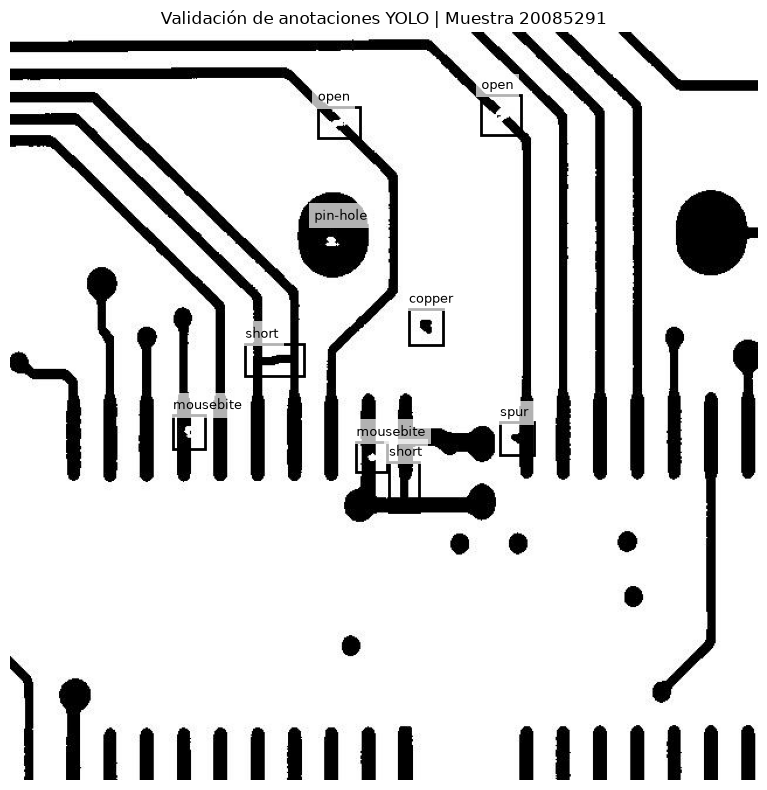

In [19]:
plot_yolo_annotations(
    image_path=sample["image_path"],
    yolo_annotations=converted_annotations
)

#### Resultado de la validación

La inspección visual confirma que las *bounding boxes* convertidas al formato YOLO mantienen correctamente su posición y dimensiones respecto de las anotaciones originales.

La reconversión temporal de las coordenadas normalizadas a píxeles produce cajas alineadas con las regiones defectuosas, lo que permite validar el procedimiento de transformación antes de aplicarlo al conjunto completo de datos.

## 4. Generación del dataset procesado

Una vez validada la conversión de las anotaciones, se genera una nueva versión del dataset con la estructura requerida por YOLO.

El dataset original almacenado en `data/raw/` se mantiene sin modificaciones. Las imágenes y etiquetas transformadas se generan dentro de `data/processed/deep_pcb_yolo/`.

La estructura resultante será:

- `images/train`: imágenes de entrenamiento.
- `images/val`: imágenes de validación.
- `images/test`: imágenes de prueba.
- `labels/train`: anotaciones YOLO de entrenamiento.
- `labels/val`: anotaciones YOLO de validación.
- `labels/test`: anotaciones YOLO de prueba.

La generación se realiza de manera reproducible a partir de las particiones definidas previamente.

In [20]:
# Crear estructura de directorios para YOLO
for split_name in ["train", "val", "test"]:
    (YOLO_DATASET_DIR / "images" / split_name).mkdir(
        parents=True,
        exist_ok=True
    )

    (YOLO_DATASET_DIR / "labels" / split_name).mkdir(
        parents=True,
        exist_ok=True
    )

print("Estructura de directorios creada correctamente.")

Estructura de directorios creada correctamente.


In [21]:
def process_split(
    split_df: pd.DataFrame,
    split_name: str,
    output_dir: Path
) -> dict:
    """
    Procesa una partición completa del dataset:

    - copia las imágenes al directorio correspondiente;
    - convierte las anotaciones al formato YOLO;
    - escribe los archivos de etiquetas.

    Devuelve un resumen del procesamiento.
    """
    images_output_dir = output_dir / "images" / split_name
    labels_output_dir = output_dir / "labels" / split_name

    processed_images = 0
    processed_labels = 0
    processed_annotations = 0

    for _, sample in split_df.iterrows():
        source_image_path = sample["image_path"]
        source_annotation_path = sample["annotation_path"]

        # Nombre final basado en sample_id
        target_image_path = (
            images_output_dir
            / f"{sample['sample_id']}{source_image_path.suffix}"
        )

        target_label_path = (
            labels_output_dir
            / f"{sample['sample_id']}.txt"
        )

        # Copiar imagen
        shutil.copy2(
            source_image_path,
            target_image_path
        )

        # Convertir anotaciones
        yolo_annotations = convert_annotation_file_to_yolo(
            annotation_path=source_annotation_path,
            image_path=source_image_path
        )

        # Escribir etiquetas YOLO
        with open(
            target_label_path,
            "w",
            encoding="utf-8"
        ) as file:
            file.write("\n".join(yolo_annotations))

            if yolo_annotations:
                file.write("\n")

        processed_images += 1
        processed_labels += 1
        processed_annotations += len(yolo_annotations)

    return {
        "split": split_name,
        "images": processed_images,
        "label_files": processed_labels,
        "annotations": processed_annotations,
    }

In [22]:
def reset_yolo_dataset_directory(
    output_dir: Path
) -> None:
    """
    Elimina y recrea el directorio del dataset procesado.
    No modifica el dataset original.
    """
    if output_dir.exists():
        shutil.rmtree(output_dir)

    for split_name in ["train", "val", "test"]:
        (output_dir / "images" / split_name).mkdir(
            parents=True,
            exist_ok=True
        )

        (output_dir / "labels" / split_name).mkdir(
            parents=True,
            exist_ok=True
        )


reset_yolo_dataset_directory(
    YOLO_DATASET_DIR
)

print(
    "Directorio del dataset procesado "
    "reiniciado correctamente."
)

Directorio del dataset procesado reiniciado correctamente.


In [23]:
processing_results = []

processing_results.append(
    process_split(
        split_df=df_train,
        split_name="train",
        output_dir=YOLO_DATASET_DIR
    )
)

processing_results.append(
    process_split(
        split_df=df_val,
        split_name="val",
        output_dir=YOLO_DATASET_DIR
    )
)

processing_results.append(
    process_split(
        split_df=df_test_final,
        split_name="test",
        output_dir=YOLO_DATASET_DIR
    )
)

df_processing_results = pd.DataFrame(
    processing_results
)

df_processing_results

,split,images,label_files,annotations
0,train,800,800,5513
1,val,200,200,1360
2,test,500,500,3140


## 5. Validación del dataset procesado

Antes de utilizar el dataset para el entrenamiento de los modelos, se realiza una auditoría automática de la estructura generada.

La validación busca comprobar:

- la correspondencia entre imágenes y archivos de etiquetas;
- la cantidad esperada de muestras por partición;
- la conservación del número total de anotaciones;
- la validez de los identificadores de clase;
- la normalización de las coordenadas YOLO dentro del rango esperado;
- la presencia de dimensiones positivas en todas las *bounding boxes*.

Estas verificaciones permiten detectar errores de conversión o inconsistencias antes de iniciar el entrenamiento.

In [24]:
def audit_yolo_split(
    dataset_dir: Path,
    split_name: str
) -> dict:
    """
    Audita una partición del dataset YOLO y verifica
    la consistencia entre imágenes y etiquetas.
    """
    images_dir = dataset_dir / "images" / split_name
    labels_dir = dataset_dir / "labels" / split_name

    image_files = sorted(images_dir.glob("*.jpg"))
    label_files = sorted(labels_dir.glob("*.txt"))

    image_ids = {path.stem for path in image_files}
    label_ids = {path.stem for path in label_files}

    images_without_labels = image_ids - label_ids
    labels_without_images = label_ids - image_ids

    total_annotations = 0
    invalid_lines = []
    invalid_classes = []
    invalid_coordinates = []

    for label_path in label_files:
        with open(label_path, "r", encoding="utf-8") as file:
            for line_number, line in enumerate(file, start=1):
                line = line.strip()

                if not line:
                    continue

                values = line.split()

                if len(values) != 5:
                    invalid_lines.append(
                        (label_path.name, line_number, line)
                    )
                    continue

                try:
                    class_id = int(values[0])
                    x_center, y_center, width, height = map(
                        float,
                        values[1:]
                    )
                except ValueError:
                    invalid_lines.append(
                        (label_path.name, line_number, line)
                    )
                    continue

                total_annotations += 1

                if class_id not in range(6):
                    invalid_classes.append(
                        (label_path.name, line_number, class_id)
                    )

                if not (
                    0.0 <= x_center <= 1.0
                    and 0.0 <= y_center <= 1.0
                    and 0.0 < width <= 1.0
                    and 0.0 < height <= 1.0
                ):
                    invalid_coordinates.append(
                        (
                            label_path.name,
                            line_number,
                            x_center,
                            y_center,
                            width,
                            height,
                        )
                    )

    return {
        "split": split_name,
        "images": len(image_files),
        "labels": len(label_files),
        "annotations": total_annotations,
        "images_without_labels": len(images_without_labels),
        "labels_without_images": len(labels_without_images),
        "invalid_lines": len(invalid_lines),
        "invalid_classes": len(invalid_classes),
        "invalid_coordinates": len(invalid_coordinates),
    }

In [25]:
audit_results = []

for split_name in ["train", "val", "test"]:
    audit_results.append(
        audit_yolo_split(
            dataset_dir=YOLO_DATASET_DIR,
            split_name=split_name
        )
    )

df_audit_results = pd.DataFrame(audit_results)

df_audit_results

,split,images,labels,annotations,images_without_labels,labels_without_images,invalid_lines,invalid_classes,invalid_coordinates
0,train,800,800,5513,0,0,0,0,0
1,val,200,200,1360,0,0,0,0,0
2,test,500,500,3140,0,0,0,0,0


In [26]:
assert (
    df_audit_results["images"].sum() == 1500
), "La cantidad total de imágenes no coincide."

assert (
    df_audit_results["labels"].sum() == 1500
), "La cantidad total de etiquetas no coincide."

assert (
    df_audit_results["annotations"].sum() == 10013
), "La cantidad total de anotaciones no coincide."

validation_columns = [
    "images_without_labels",
    "labels_without_images",
    "invalid_lines",
    "invalid_classes",
    "invalid_coordinates",
]

assert (
    df_audit_results[validation_columns]
    .to_numpy()
    .sum() == 0
), "Se detectaron inconsistencias en el dataset procesado."

print(
    "Dataset procesado validado correctamente: "
    "1500 imágenes, 1500 etiquetas y 10013 anotaciones."
)

Dataset procesado validado correctamente: 1500 imágenes, 1500 etiquetas y 10013 anotaciones.


## 6. Creación del archivo `data.yaml`

Ultralytics YOLO requiere un archivo de configuración en formato YAML que indique la ubicación del dataset, las particiones disponibles y los nombres de las clases.

Este archivo será utilizado posteriormente para entrenar y evaluar los modelos YOLO Nano y YOLO Small.

In [27]:
data_yaml_content = f"""path: {YOLO_DATASET_DIR.as_posix()}
train: images/train
val: images/val
test: images/test

names:
  0: open
  1: short
  2: mousebite
  3: spur
  4: copper
  5: pin-hole
"""

data_yaml_path = YOLO_DATASET_DIR / "data.yaml"

with open(data_yaml_path, "w", encoding="utf-8") as file:
    file.write(data_yaml_content)

print(data_yaml_content)
print(f"Archivo creado en: {data_yaml_path}")

path: c:/Users/zakiea/Desktop/DL/TP Final/pcb-defect-detection-yolo/data/processed/deep_pcb_yolo
train: images/train
val: images/val
test: images/test

names:
  0: open
  1: short
  2: mousebite
  3: spur
  4: copper
  5: pin-hole

Archivo creado en: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\processed\deep_pcb_yolo\data.yaml


In [28]:
assert data_yaml_path.exists(), "No se creó data.yaml."

print("data.yaml creado correctamente.")

data.yaml creado correctamente.
